# Tidal track universality

[Errani+21](https://arxiv.org/abs/2011.07077) and [Du+24](https://arxiv.org/abs/2403.09597) both claim that the tidal track of a stripped subhalo — the trajectory $(R_{\rm max}/R_{\rm max,0}, V_{\rm max}/V_{\rm max,0})$ as the subhalo loses mass — is approximately *universal* for a given initial inner-slope $\gamma$. For Navarro-Frenk-White subhalos ($\gamma=1$), the shape of the track should be insensitive to the subhalo's total mass and concentration, to the host's mass and concentration, and to the orbital parameters — only the *rate* at which the subhalo moves along the track depends on those parameters.

This notebook tests that claim under the **Benson+Du22 calibration** of `evolve_heating` ($\varepsilon_h=3$, $\gamma_h=1.5$, $\beta_h=1$, $\alpha_s=1$, default $f_2=0.406$, $\chi_v=-0.333$). The same calibration matches Errani+Navarro 2021 in the SIS-host notebook and brings the NFW-host track onto Du+24 eq. (19) within a few percent over $r_{\rm max}/r_{\rm max,0} \in [0.15, 1]$.

We do *not* use Du+24's NFW-host refit ($\varepsilon_h=0.0741$, $\gamma_h=0$, $\beta_h=0.278$, $\alpha_s=3.93$, $f_2=0.547$): that refit is calibrated against Galacticus's $P_{10}$-family parametric profile evolution and its tidal-radius dynamical-time `useDynamicalTimeScale` convention — neither of which our `heat_profile` + hard-truncation-at-$l_t$ + orbital-period $t_{\rm orb}$ implementation uses.

Six sweeps:
- subhalo mass $M_{\rm sub} \in [10^6, 10^9]\,M_\odot$ at fixed $c_{\rm sub} = 15$
- subhalo concentration $c_{\rm sub} \in [10, 26]$ at fixed $M_{\rm sub} = 10^9\,M_\odot$
- host mass $M_{\rm host} \in [10^9, 10^{12}]\,M_\odot$ from Segue-I-like UFD to Milky-Way at fixed $c_{\rm host} = 11.68$
- host concentration $c_{\rm host} \in [5, 20]$ at fixed $M_{\rm host} = 10^{12}\,M_\odot$
- apocenter $R_0 / r_{\rm vir,host} \in [0.3, 1.0]$ at fixed $\eta = 0.21$
- circularity $\eta = V_\phi/V_{\rm c} \in [0.10, 0.80]$ at fixed $R_0 = 0.7\,r_{\rm vir,host}$ ($\eta=1$ is circular; smaller is more radial)

All other parameters held fixed within each sweep. Subhalo profile hard-cut at $10\,r_s$, evolution time $30\,{\rm Gyr}$ over $3\cdot10^4$ steps.

Reference curve: Du+24 eq. (19) parametric fit with Table I row $(\alpha,\beta,\gamma)=(1,3,1)$.

In [1]:
import numpy as np
import matplotlib as mpl
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['font.size'] = 13
import matplotlib.pyplot as plt
from multiprocessing import Pool
import os

%matplotlib inline
%load_ext autoreload
%autoreload 2

import tidal_track_helpers as h
from tidal_track_helpers import evolve_one, du24_eq19, median_track_ratio

>>> Normalizing primordial power spectrum P(k)=(k/k_0)^n_s ...
    such that sigma(R=8Mpc/h) =   0.8000.
>>> Tabulating sigma(M,z=0) ...


    From now on, sigma(M,z) is computed by interpolation.
>>> Tabulating z(W) and z(t_lkbk)...
>>> Preparing output redshifts for merger trees ...
    Number of output redshifts =  354, up to z = 20.06
>>> Tabulating Parkinson+08 J(u_res) ...
>>> Building interpolation grid for Green+19 M(<r|f_b,c)...
>>> Building interpolation grid for Green+19 sigma(r|f_b,c)...
>>> Building interpolation grid for Green+19 d2Phidr2(r|f_b,c)...
>>> Building interpolator for Jiang+15 orbit sampler...


## Sweep parameter sets

Each sweep holds three of the four (M_sub, c_sub, M_host, c_host) parameters fixed and varies the fourth across four values. All evolutions run in parallel via `multiprocessing.Pool` sized to `cpu_count() - 2`.

In [2]:
C_SUB_FID  = 15.
M_SUB_FID  = 1e9
M_HOST_FID = 1e12
C_HOST_FID = 11.68

sweep_M_sub = [
    dict(M_sub=M, c_sub=C_SUB_FID, M_host=M_HOST_FID, c_host=C_HOST_FID)
    for M in (1e6, 1e7, 1e8, 1e9)
]
sweep_c_sub = [
    dict(M_sub=M_SUB_FID, c_sub=c, M_host=M_HOST_FID, c_host=C_HOST_FID)
    for c in (10., 15., 20., 26.)
]
sweep_M_host = [
    dict(M_sub=M_SUB_FID*1e-3, c_sub=C_SUB_FID, M_host=Mh, c_host=C_HOST_FID)
    for Mh in (1e9, 1e10, 1e11, 1e12)
]
sweep_c_host = [
    dict(M_sub=M_SUB_FID, c_sub=C_SUB_FID, M_host=M_HOST_FID, c_host=ch)
    for ch in (5., 10., 15., 20.)
]
sweep_R0 = [
    dict(M_sub=M_SUB_FID, c_sub=C_SUB_FID, M_host=M_HOST_FID, c_host=C_HOST_FID, R0_frac=R0f)
    for R0f in (0.3, 0.5, 0.7, 1.0)
]
sweep_eta = [
    dict(M_sub=M_SUB_FID, c_sub=C_SUB_FID, M_host=M_HOST_FID, c_host=C_HOST_FID, eta=e)
    for e in (0.10, 0.30, 0.50, 0.80)
]

all_runs = sweep_M_sub + sweep_c_sub + sweep_M_host + sweep_c_host + sweep_R0 + sweep_eta
print(f'Total runs: {len(all_runs)}')

Total runs: 24


In [3]:
import time
n_proc = max(1, (os.cpu_count() or 4) - 2)  # leave a couple cores free
print(f'Running on {n_proc} processes')
t0 = time.time()
with Pool(processes=n_proc) as pool:
    results = pool.map(evolve_one, all_runs)
print(f'Total wall time: {time.time()-t0:.1f} s')

n = len(sweep_M_sub)
res_M_sub   = results[0*n:1*n]
res_c_sub   = results[1*n:2*n]
res_M_host  = results[2*n:3*n]
res_c_host  = results[3*n:4*n]
res_R0      = results[4*n:5*n]
res_eta     = results[5*n:6*n]

Running on 16 processes


>>> Normalizing primordial power spectrum P(k)=(k/k_0)^n_s ...
    such that sigma(R=8Mpc/h) =   0.8000.
>>> Tabulating sigma(M,z=0) ...
    From now on, sigma(M,z) is computed by interpolation.
>>> Tabulating z(W) and z(t_lkbk)...
>>> Preparing output redshifts for merger trees ...
    Number of output redshifts =  354, up to z = 20.06
>>> Tabulating Parkinson+08 J(u_res) ...
>>> Building interpolation grid for Green+19 M(<r|f_b,c)...
>>> Building interpolation grid for Green+19 sigma(r|f_b,c)...
>>> Building interpolation grid for Green+19 d2Phidr2(r|f_b,c)...
>>> Building interpolator for Jiang+15 orbit sampler...
>>> Normalizing primordial power spectrum P(k)=(k/k_0)^n_s ...
    such that sigma(R=8Mpc/h) =   0.8000.
>>> Tabulating sigma(M,z=0) ...
    From now on, sigma(M,z) is computed by interpolation.
>>> Tabulating z(W) and z(t_lkbk)...
>>> Preparing output redshifts for merger trees ...
    Number of output redshifts =  354, up to z = 20.06
>>> Tabulating Parkinson+08 J(u_res)

## Plot each sweep

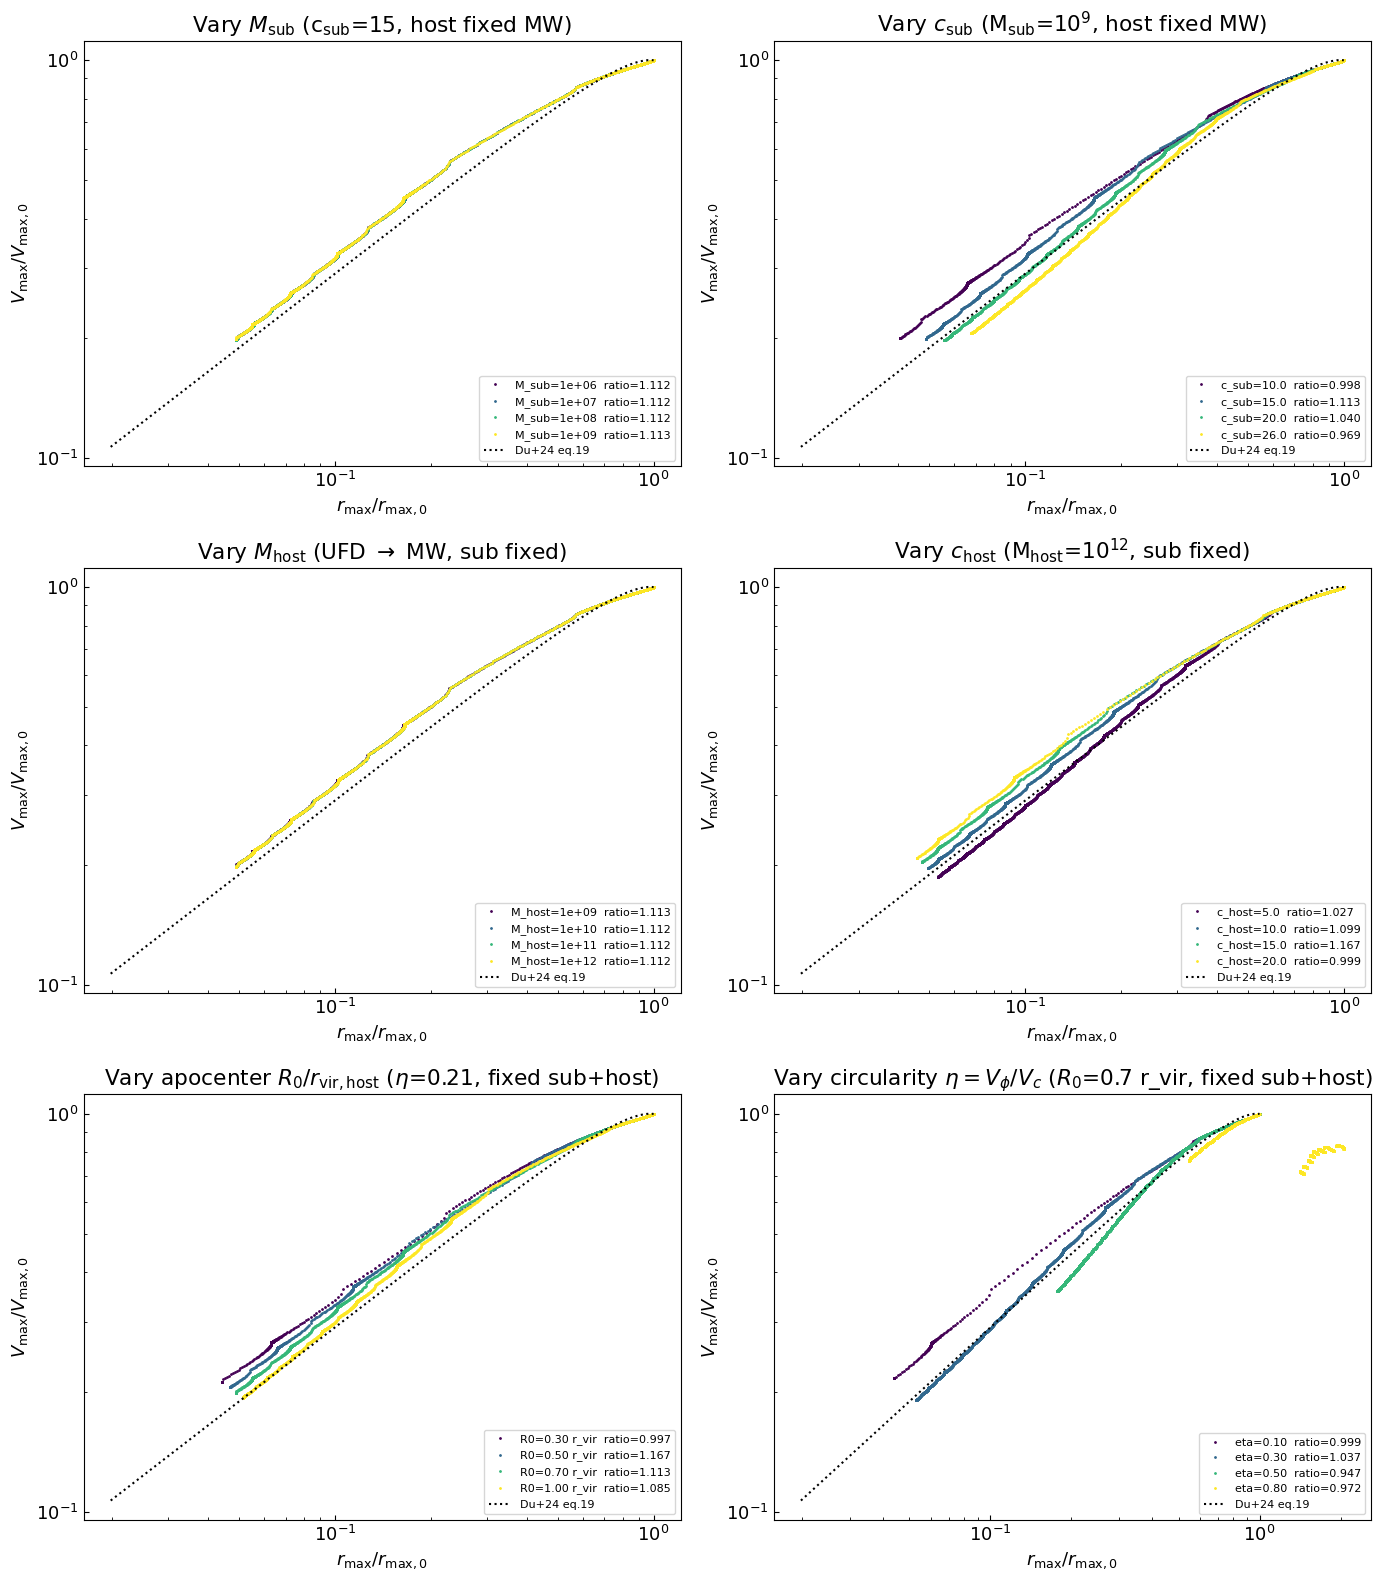

In [4]:
def plot_sweep(ax, results, label_fmt, vary_key):
    cmap = plt.get_cmap('viridis')
    n = len(results)
    for i, r in enumerate(results):
        ratio = median_track_ratio(r['R'], r['V'])
        c = cmap(i / max(n - 1, 1))
        lab = label_fmt.format(**r) + f'  ratio={ratio:.3f}'
        ax.plot(r['R'], r['V'], '.', ms=2, color=c, label=lab)
    x_ref = np.logspace(-4, 0, 400)
    R_ref, V_ref = du24_eq19(x_ref)
    ax.plot(R_ref, V_ref, 'k:', lw=1.5, label='Du+24 eq.19', zorder=5)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel(r'$r_{\rm max}/r_{\rm max,0}$')
    ax.set_ylabel(r'$V_{\rm max}/V_{\rm max,0}$')
    ax.legend(fontsize=8, loc='lower right')

fig, axes = plt.subplots(3, 2, figsize=(14, 16))
plot_sweep(axes[0,0], res_M_sub,  'M_sub={M_sub:.0e}',  'M_sub')
axes[0,0].set_title(r'Vary $M_{\rm sub}$ (c$_{\rm sub}$=15, host fixed MW)')
plot_sweep(axes[0,1], res_c_sub,  'c_sub={c_sub:.1f}',  'c_sub')
axes[0,1].set_title(r'Vary $c_{\rm sub}$ (M$_{\rm sub}$=$10^9$, host fixed MW)')
plot_sweep(axes[1,0], res_M_host, 'M_host={M_host:.0e}', 'M_host')
axes[1,0].set_title(r'Vary $M_{\rm host}$ (UFD $\to$ MW, sub fixed)')
plot_sweep(axes[1,1], res_c_host, 'c_host={c_host:.1f}', 'c_host')
axes[1,1].set_title(r'Vary $c_{\rm host}$ (M$_{\rm host}$=$10^{12}$, sub fixed)')
plot_sweep(axes[2,0], res_R0,     'R0={R0_frac:.2f} r_vir', 'R0_frac')
axes[2,0].set_title(r'Vary apocenter $R_0/r_{\rm vir,host}$ ($\eta$=0.21, fixed sub+host)')
plot_sweep(axes[2,1], res_eta,    'eta={eta:.2f}',          'eta')
axes[2,1].set_title(r'Vary circularity $\eta = V_\phi/V_c$ ($R_0$=0.7 r_vir, fixed sub+host)')
fig.tight_layout()
plt.show()

## All sweeps overlaid

Sixteen tracks on the same axes. If the universality claim holds, they all trace the same curve — only the *endpoint* of each track (how far along it the subhalo has progressed by `tmax`=30 Gyr) reflects the parameter variation.

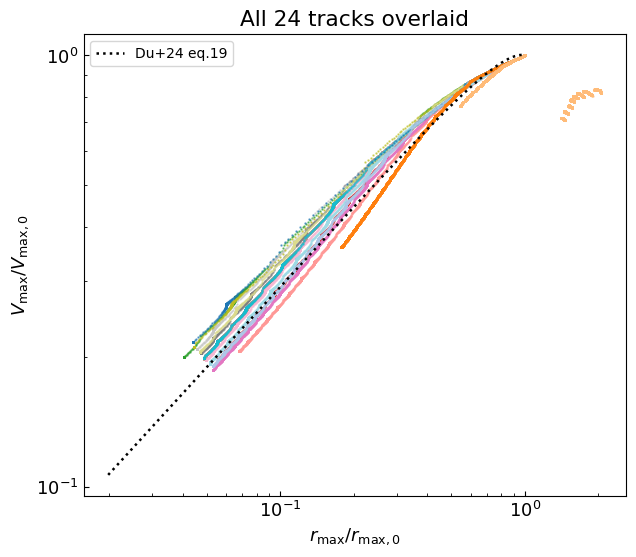

In [5]:
fig, ax = plt.subplots(figsize=(7, 6))
for i, r in enumerate(results):
    ax.plot(r['R'], r['V'], '.', ms=1.5, alpha=0.6,
            color=plt.cm.tab20(i % 20))
x_ref = np.logspace(-4, 0, 400)
R_ref, V_ref = du24_eq19(x_ref)
ax.plot(R_ref, V_ref, 'k:', lw=1.8, label='Du+24 eq.19', zorder=10)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$r_{\rm max}/r_{\rm max,0}$')
ax.set_ylabel(r'$V_{\rm max}/V_{\rm max,0}$')
ax.set_title(f'All {len(results)} tracks overlaid')
ax.legend(fontsize=10)
plt.show()

## Median ratio summary

Quantify the agreement: median $V/V_{\rm Du+24}$ over $R/R_0 \in [0.1, 1.0]$ for each run. Values near 1 mean the track lies on the Du+24 fit. Spread within a sweep measures how much the parameter affects the track *shape*.

In [6]:
def report(name, results, key):
    ratios = [median_track_ratio(r['R'], r['V']) for r in results]
    finals = [r['m_final_over_M_tot'] for r in results]
    vals = [r[key] for r in results]
    print(f'\n{name} sweep:')
    print(f'  {"value":>10s}  {"ratio Du+24":>12s}  {"final m/M_tot":>14s}')
    for v, ratio, fm in zip(vals, ratios, finals):
        print(f'  {v:>10.2e}  {ratio:>12.3f}  {fm:>14.3e}')
    print(f'  spread (max-min)/median = {(max(ratios)-min(ratios))/np.median(ratios):.1%}')

report('M_sub',  res_M_sub,  'M_sub')
report('c_sub',  res_c_sub,  'c_sub')
report('M_host', res_M_host, 'M_host')
report('c_host', res_c_host, 'c_host')
report('R0',     res_R0,     'R0_frac')
report('eta',    res_eta,    'eta')


M_sub sweep:
       value   ratio Du+24   final m/M_tot
    1.00e+06         1.112       1.233e-03
    1.00e+07         1.112       1.233e-03
    1.00e+08         1.112       1.233e-03
    1.00e+09         1.113       1.233e-03
  spread (max-min)/median = 0.1%

c_sub sweep:
       value   ratio Du+24   final m/M_tot
    1.00e+01         0.998       1.000e-03
    1.50e+01         1.113       1.233e-03
    2.00e+01         1.040       1.405e-03
    2.60e+01         0.969       1.811e-03
  spread (max-min)/median = 14.1%

M_host sweep:
       value   ratio Du+24   final m/M_tot
    1.00e+09         1.113       1.233e-03
    1.00e+10         1.112       1.233e-03
    1.00e+11         1.112       1.233e-03
    1.00e+12         1.112       1.233e-03
  spread (max-min)/median = 0.1%

c_host sweep:
       value   ratio Du+24   final m/M_tot
    5.00e+00         1.027       1.233e-03
    1.00e+01         1.099       1.233e-03
    1.50e+01         1.167       1.233e-03
    2.00e+01         0.99

## Discussion

Universality across subhalo, host, and orbit parameters is what's predicted by Errani+21 and Du+24 — the tidal track shape depends only on the initial *inner slope* $\gamma$ (we use $\gamma=1$, NFW, throughout). With the Benson+Du22 calibration, the same parameter set that hits Errani+Navarro 2021 on a SIS host puts the NFW-host track close to Du+24 eq. (19). The remaining spread within sweeps is small and consistent with Du+24's own measurements: Du+24 Fig. 1 shows visible (but small) $c_{\rm sub}$-dependence, and their eq. (19) is a single-$c$ fit (calibrated at $c_{\rm sub}=20.58$).

The *endpoint* of each track depends on how aggressively the subhalo strips, which is set by host concentration (sets tidal field amplitude), orbit eccentricity, and the King62 rate. Subhalo mass doesn't matter because the heating kernel scales self-similarly. Host mass mostly affects the orbital timescale. Orbit parameters ($R_0$, $\eta$) shift the endpoint (more eccentric / smaller-pericenter orbits strip faster) but should preserve the track shape.

The fact that Benson+Du22 calibration works on both SIS and NFW hosts — while Du+24's NFW-host refit (eps_h=0.0741, alpha_s=3.93) does not give a better fit in our implementation — supports the hypothesis that Du+24's refit is tuned to two Galacticus-specific choices: the $P_{10}$ one-parameter ($\alpha,\beta,\gamma$)-profile-family evolution that forces Errani+Navarro2021-track compliance, and the `useDynamicalTimeScale` convention that uses $T_{\rm dyn}(l_t)$ rather than the orbital period as the King62 stripping timescale. Our `heat_profile` + hard-truncation-at-$l_t$ + orbital-period stripping pipeline differs from both, so Du+24's NFW-host coefficients don't transfer.